<a href="https://colab.research.google.com/github/pengin-cmd/my-colab-notebooks/blob/main/%E3%82%B3%E3%83%B3%E3%83%9A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install xgboost catboost optuna lightgbm

In [10]:
!pip install optuna

In [11]:
pip install lifetimes


--- [1. Optuna パラメータ最適化] ---

--- [2. 学習フェーズ開始] ---
>> Running Seed: 42...
>> Running Seed: 2023...
  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: -29.76612185609717
        x: [ 3.612e-01 -3.159e+00 -5.569e+00 -5.078e-01]
      nit: 31
      jac: [-1.066e-07  9.558e-08  1.323e-09  3.714e-10]
 hess_inv: [[ 3.523e+00  4.333e+00 -1.259e+01 -4.661e+00]
            [ 4.333e+00  6.192e+00 -1.837e+01 -7.089e+00]
            [-1.259e+01 -1.837e+01  2.687e+02  9.954e+01]
            [-4.661e+00 -7.089e+00  9.954e+01  8.426e+01]]
     nfev: 76
     njev: 64
      [BTYD Info] penalizer_coef=0.05 で収束に成功しました。
>> Running Seed: 777...
✅ 学習完了: 最終 OOF AUC: 0.8714

--- [3. 予測フェーズ開始] ---
✅ 予測完了: 計 45 個のモデルによる予測を実行しました。

--- [4. エラー分析] ---
▼ エラー件数: 232 件 / 1568 件

▼ 損失原因度 トップ5:
                Feature  Error_Importance
0        recent_loyalty         12.199079
1            prob_alive          9.694820
2  store_reliance_ratio          8.5

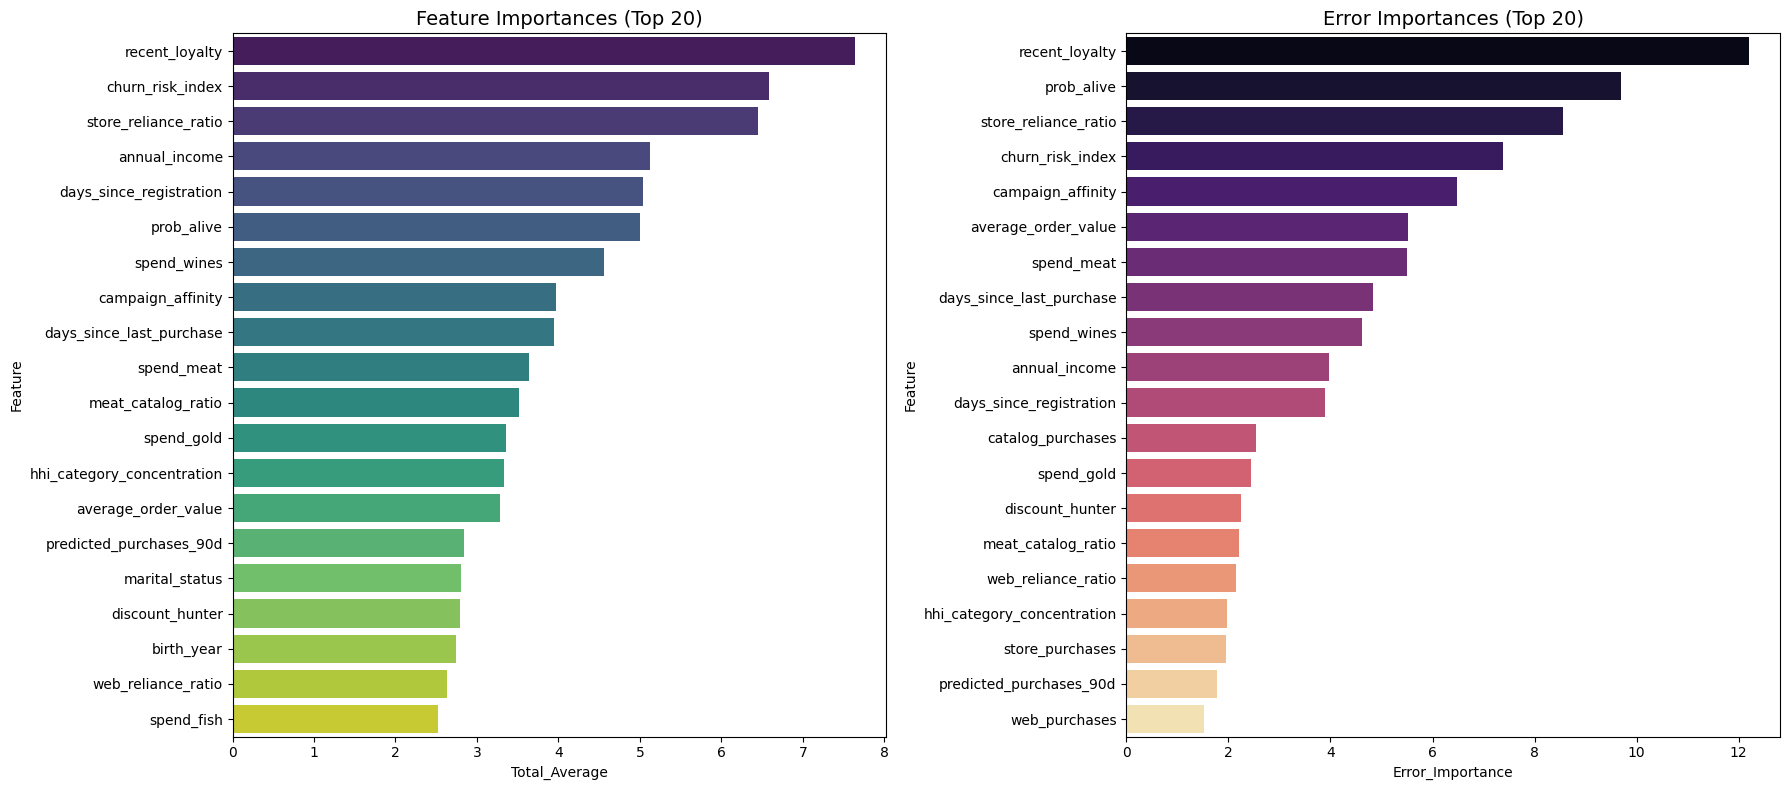


✅ 全工程完了: 'final_submission_perfect_leakfree.csv' を出力しました！


In [14]:
import pandas as pd
import numpy as np
import warnings
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier, export_text
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from lifetimes import BetaGeoFitter

warnings.filterwarnings('ignore')

# ==========================================
# 0. リークしない事前処理（行単位の処理）
# ==========================================
def preprocess_safe_row_wise(df):
    df = df.copy()
    base_date = pd.to_datetime('2015-01-01')

    if 'registration_date' in df.columns:
        df['days_since_registration'] = (base_date - pd.to_datetime(df['registration_date'])).dt.days
        df = df.drop('registration_date', axis=1)

    # --- 💡 特徴量エンジニアリング（エース達の完全復活） ---
    # 1. 一見さん排除フィルター (recent_loyalty)
    if all(c in df.columns for c in ['spend_wines', 'spend_meat', 'days_since_last_purchase']):
        df['recent_loyalty'] = (df['spend_wines'] + df['spend_meat']) / (df['days_since_last_purchase'] + 1)

    # 2. カタログと肉の相性
    if all(c in df.columns for c in ['spend_meat', 'catalog_purchases']):
        df['meat_catalog_ratio'] = df['spend_meat'] / (df['catalog_purchases'] + 1)

    # 3. 割引ハンター度 & キャンペーン相性
    if all(c in df.columns for c in ['deals_purchases', 'store_purchases', 'web_purchases', 'catalog_purchases']):
        total_purchases = df['store_purchases'] + df['web_purchases'] + df['catalog_purchases']
        df['discount_hunter'] = df['deals_purchases'] / (total_purchases + 1)
        if 'recent_loyalty' in df.columns:
            df['campaign_affinity'] = df['recent_loyalty'] * df['discount_hunter']

    # --- 💡 経営学・マーケティング理論に基づく新特徴量 ---
    # 1. AOV (客単価)
    if all(c in df.columns for c in ['store_purchases', 'web_purchases', 'catalog_purchases',
                                     'spend_wines', 'spend_fruits', 'spend_meat', 'spend_fish', 'spend_sweets', 'spend_gold']):
        total_purchases = df['store_purchases'] + df['web_purchases'] + df['catalog_purchases']
        total_spend = df['spend_wines'] + df['spend_fruits'] + df['spend_meat'] + df['spend_fish'] + df['spend_sweets'] + df['spend_gold']
        df['average_order_value'] = total_spend / (total_purchases + 1)

        # 2. HHI (購買カテゴリの集中度)
        share_wines = df['spend_wines'] / (total_spend + 1)
        share_fruits = df['spend_fruits'] / (total_spend + 1)
        share_meat = df['spend_meat'] / (total_spend + 1)
        share_fish = df['spend_fish'] / (total_spend + 1)
        share_sweets = df['spend_sweets'] / (total_spend + 1)
        share_gold = df['spend_gold'] / (total_spend + 1)
        df['hhi_category_concentration'] = (share_wines**2 + share_fruits**2 + share_meat**2 +
                                            share_fish**2 + share_sweets**2 + share_gold**2)

    # 3. オムニチャネル依存度
    if all(c in df.columns for c in ['store_purchases', 'web_purchases', 'catalog_purchases']):
        total_purchases_for_ratio = df['store_purchases'] + df['web_purchases'] + df['catalog_purchases']
        df['store_reliance_ratio'] = df['store_purchases'] / (total_purchases_for_ratio + 1)
        df['web_reliance_ratio'] = df['web_purchases'] / (total_purchases_for_ratio + 1)

    # 4. 休眠リスク指数
    if all(c in df.columns for c in ['days_since_last_purchase', 'days_since_registration']):
        df['churn_risk_index'] = df['days_since_last_purchase'] / (df['days_since_registration'] + 1)

    return df

# ==========================================
# 0.5 BTYDモデル (リークフリー完全分離版)
# ==========================================
# ==========================================
# 0.5 BTYDモデル (例外処理による自動リトライ機能付き)
# ==========================================
def fit_btyd(train_df):
    """TrainデータからBTYDモデルを学習する（例外処理で収束を保証）"""
    df = train_df.copy()
    df['frequency'] = df['store_purchases'] + df['web_purchases'] + df['catalog_purchases']
    df['T'] = df['days_since_registration']
    df['recency'] = (df['T'] - df['days_since_last_purchase']).clip(lower=0)

    train_btyd = df[df['frequency'] > 0]

    # 💡 例外処理：ペナライザーを徐々に強くしながらリトライする
    penalizers_to_try = [0.01, 0.05, 0.1, 0.5, 1.0]
    bgf = None

    for pen in penalizers_to_try:
        try:
            # モデルの初期化と学習
            temp_bgf = BetaGeoFitter(penalizer_coef=pen)
            temp_bgf.fit(train_btyd['frequency'], train_btyd['recency'], train_btyd['T'])

            # エラーが出ずにここまで来たら成功！
            bgf = temp_bgf
            # Optunaなどの大量ログの中で埋もれないよう、リトライが発生した時だけ出力
            if pen > 0.01:
                print(f"      [BTYD Info] penalizer_coef={pen} で収束に成功しました。")
            break # 成功したのでループを抜ける

        except Exception as e:
            # 収束エラー(ConvergenceError等)が出た場合は次のペナライザーを試す
            pass

    # 全て失敗した場合の究極の安全網（1.0でも失敗することは通常あり得ませんが念のため）
    if bgf is None:
        print("      [BTYD ERROR] 全てのペナライザーで収束失敗。最も強いペナルティで強制処理します。")
        bgf = BetaGeoFitter(penalizer_coef=10.0)
        bgf.fit(train_btyd['frequency'], train_btyd['recency'], train_btyd['T'])

    return bgf

def transform_btyd(target_df, bgf):
    """学習済みBTYDモデルを使って特徴量を付与する（Numpyエラー対策版）"""
    df = target_df.copy()
    df['frequency'] = df['store_purchases'] + df['web_purchases'] + df['catalog_purchases']
    df['T'] = df['days_since_registration']
    df['recency'] = (df['T'] - df['days_since_last_purchase']).clip(lower=0)

    # lifetimesの出力が numpy.ndarray になるケースに対応するため、
    # 一度 pd.Series にラップし、元の df.index を明示的に紐付けてから fillna を行う
    prob_alive = bgf.conditional_probability_alive(df['frequency'], df['recency'], df['T'])
    df['prob_alive'] = pd.Series(prob_alive, index=df.index).fillna(1.0)

    pred_90d = bgf.conditional_expected_number_of_purchases_up_to_time(90, df['frequency'], df['recency'], df['T'])
    df['predicted_purchases_90d'] = pd.Series(pred_90d, index=df.index).fillna(0)

    df = df.drop(columns=['frequency', 'T', 'recency'])
    return df

# ==========================================
# 1. Optuna (パラメータチューニング)
# ==========================================
def tune_lightgbm_with_optuna(X_raw, y, n_trials=10):
    print("\n--- [1. Optuna パラメータ最適化] ---")
    def objective(trial):
        params = {
            'random_state': 42,
            'n_estimators': 500,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'num_leaves': trial.suggest_int('num_leaves', 15, 63),
            'class_weight': 'balanced',
            'verbose': -1
        }
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        oof = np.zeros(len(X_raw))
        for tr_idx, va_idx in skf.split(X_raw, y):
            X_tr_raw, y_tr = X_raw.iloc[tr_idx].copy(), y.iloc[tr_idx]
            X_va_raw, y_va = X_raw.iloc[va_idx].copy(), y.iloc[va_idx]

            # --- ルール作成 (Fit) ---
            income_median = X_tr_raw['annual_income'].median()
            cols = ['education_level', 'marital_status']
            enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            enc.fit(X_tr_raw[cols])
            fitted_bgf = fit_btyd(X_tr_raw) # Optuna内でもリーク対策

            # --- 変形 (Transform) ---
            X_tr = X_tr_raw.copy()
            X_va = X_va_raw.copy()

            X_tr = transform_btyd(X_tr, fitted_bgf)
            X_va = transform_btyd(X_va, fitted_bgf)

            X_tr['annual_income'] = X_tr['annual_income'].fillna(income_median)
            X_va['annual_income'] = X_va['annual_income'].fillna(income_median)

            X_tr[cols] = enc.transform(X_tr[cols])
            X_va[cols] = enc.transform(X_va[cols])

            model = LGBMClassifier(**params)
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[early_stopping(stopping_rounds=30, verbose=False)])
            oof[va_idx] = model.predict_proba(X_va)[:, 1]
        return roc_auc_score(y, oof)

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    best_params = study.best_params
    best_params.update({'random_state': 42, 'n_estimators': 1000, 'class_weight': 'balanced', 'verbose': -1})
    return best_params

# ==========================================
# 2. 学習フェーズ (真のリークフリー版)
# ==========================================
def train_models(X_raw, y, lgb_best_params, seeds=[42, 2023, 777], n_splits=5):
    print(f"\n--- [2. 学習フェーズ開始] ---")
    artifacts = []
    oof_preds_ensemble = np.zeros(len(X_raw))
    ratio = float(np.sum(y == 0)) / np.sum(y == 1)

    for seed in seeds:
        print(f">> Running Seed: {seed}...")
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        oof_seed = np.zeros(len(X_raw))

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_raw, y)):
            # データの切り出し（原本）
            X_tr_raw, y_tr = X_raw.iloc[train_idx].copy(), y.iloc[train_idx]
            X_va_raw, y_va = X_raw.iloc[val_idx].copy(), y.iloc[val_idx]

            # ==================================
            # フェーズ1: ルールの作成（Fit）
            # ==================================
            income_median = X_tr_raw['annual_income'].median()
            categorical_cols = ['education_level', 'marital_status']
            encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            encoder.fit(X_tr_raw[categorical_cols])
            fitted_bgf = fit_btyd(X_tr_raw) # 🌟 ここでBTYDを学習

            # ==================================
            # フェーズ2: データの変形（Transform）
            # ==================================
            X_tr = X_tr_raw.copy()
            X_va = X_va_raw.copy()

            # BTYD特徴量の付与
            X_tr = transform_btyd(X_tr, fitted_bgf)
            X_va = transform_btyd(X_va, fitted_bgf)

            # 欠損値とカテゴリの処理
            X_tr['annual_income'] = X_tr['annual_income'].fillna(income_median)
            X_va['annual_income'] = X_va['annual_income'].fillna(income_median)
            X_tr[categorical_cols] = encoder.transform(X_tr[categorical_cols])
            X_va[categorical_cols] = encoder.transform(X_va[categorical_cols])

            # モデルの学習
            lgb_params = lgb_best_params.copy()
            lgb_params['random_state'] = seed

            models = {
                'LightGBM': LGBMClassifier(**lgb_params),
                'XGBoost': XGBClassifier(random_state=seed, n_estimators=1000, learning_rate=0.05, max_depth=5, scale_pos_weight=ratio, early_stopping_rounds=50, eval_metric='logloss'),
                'RandomForest': RandomForestClassifier(random_state=seed, n_estimators=100, max_depth=10, class_weight='balanced')
            }

            fold_val_preds = np.zeros(len(X_va))
            for name, model in models.items():
                if name == 'LightGBM':
                    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[early_stopping(stopping_rounds=30, verbose=False)])
                elif name == 'XGBoost':
                    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
                else:
                    model.fit(X_tr, y_tr)
                fold_val_preds += model.predict_proba(X_va)[:, 1] / len(models)

            oof_seed[val_idx] = fold_val_preds

            # Artifactsの保存
            artifacts.append({
                'seed': seed, 'fold': fold,
                'preprocessors': {
                    'income_median': income_median,
                    'encoder': encoder,
                    'cat_cols': categorical_cols,
                    'btyd_model': fitted_bgf # 🌟 BTYDモデルも保存
                },
                'models': models, 'feature_names': list(X_tr.columns)
            })
        oof_preds_ensemble += oof_seed / len(seeds)

    print(f"✅ 学習完了: 最終 OOF AUC: {roc_auc_score(y, oof_preds_ensemble):.4f}")
    return artifacts, oof_preds_ensemble

# ==========================================
# 3. 予測フェーズ
# ==========================================
def predict_models(X_test_raw, artifacts):
    print("\n--- [3. 予測フェーズ開始] ---")
    final_test_preds = np.zeros(len(X_test_raw))
    total_models = 0
    for artifact in artifacts:
        X_te = X_test_raw.copy()
        preps = artifact['preprocessors']
        models = artifact['models']

        # 🌟 Trainで学習済みのBTYDモデルをTestに適用
        X_te = transform_btyd(X_te, preps['btyd_model'])

        X_te['annual_income'] = X_te['annual_income'].fillna(preps['income_median'])
        X_te[preps['cat_cols']] = preps['encoder'].transform(X_te[preps['cat_cols']])

        for name, model in models.items():
            final_test_preds += model.predict_proba(X_te)[:, 1]
            total_models += 1

    final_test_preds /= total_models
    print(f"✅ 予測完了: 計 {total_models} 個のモデルによる予測を実行しました。")
    return final_test_preds

# ==========================================
# 4 & 5. 可視化・分析
# ==========================================
def analyze_and_plot(X_raw_with_btyd, y, oof_preds, artifacts):
    print("\n--- [4. エラー分析] ---")
    error_df = X_raw_with_btyd.copy()
    error_df['target'] = y
    error_df['pred_class'] = (oof_preds >= 0.5).astype(int)
    error_df['is_error'] = (error_df['target'] != error_df['pred_class']).astype(int)
    print(f"▼ エラー件数: {error_df['is_error'].sum()} 件 / {len(error_df)} 件")

    X_error = X_raw_with_btyd.copy()
    X_error['annual_income'] = X_error['annual_income'].fillna(X_error['annual_income'].median())
    cols = ['education_level', 'marital_status']
    X_error[cols] = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit_transform(X_error[cols])

    error_model = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, class_weight='balanced')
    error_model.fit(X_error, error_df['is_error'])
    error_importance = pd.DataFrame({'Feature': X_error.columns, 'Error_Importance': error_model.feature_importances_ * 100}).sort_values(by='Error_Importance', ascending=False).reset_index(drop=True)

    print("\n▼ 損失原因度 トップ5:")
    print(error_importance.head(5))

    f_names = artifacts[0]['feature_names']
    importance_df = pd.DataFrame({'Feature': f_names})
    total_imps = np.zeros(len(f_names))
    total_models = 0
    scaler = MinMaxScaler()
    for art in artifacts:
        for name, model in art['models'].items():
            raw_imp = model.feature_importances_
            scaled_imp = scaler.fit_transform(raw_imp.reshape(-1, 1)).flatten()
            total_imps += scaled_imp
            total_models += 1

    importance_df['Total_Average'] = (total_imps / total_models)
    importance_df['Total_Average'] = (importance_df['Total_Average'] / importance_df['Total_Average'].sum()) * 100
    importance_df = importance_df.sort_values(by='Total_Average', ascending=False).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    sns.barplot(x='Total_Average', y='Feature', data=importance_df.head(20), palette='viridis', ax=axes[0])
    axes[0].set_title('Feature Importances (Top 20)', fontsize=14)
    sns.barplot(x='Error_Importance', y='Feature', data=error_importance.head(20), palette='magma', ax=axes[1])
    axes[1].set_title('Error Importances (Top 20)', fontsize=14)
    plt.tight_layout()
    plt.show()

# ==========================================
# メイン実行ブロック
# ==========================================
if __name__ == "__main__":
    train_data = pd.read_csv('train.csv')
    test_data = pd.read_csv('test.csv')

    # ① データの準備（BTYDはここではまだやらない！）
    train_df = preprocess_safe_row_wise(train_data)
    test_df = preprocess_safe_row_wise(test_data)

    X_raw = train_df.drop(['customer_id', 'target'], axis=1)
    y = train_df['target']

    # 🚨ターゲット列の削除を徹底
    X_test_raw = test_df.drop(['customer_id', 'target'], axis=1, errors='ignore')

    # ② パラメータ最適化
    best_lgb_params = tune_lightgbm_with_optuna(X_raw, y, n_trials=10)

    # ③ 学習フェーズ（この中でCVごとにBTYDを計算する）
    artifacts, oof_predictions = train_models(X_raw, y, best_lgb_params)

    # ④ 予測フェーズ
    final_predictions = predict_models(X_test_raw, artifacts)

    # ⑤ 分析・可視化
    # ⚠️可視化のために、全体データに対して一度BTYDを適用したダミーを用意する
    # （※これは分析用であり、予測モデルには一切影響しません）
    dummy_bgf = fit_btyd(X_raw)
    X_raw_for_plot = transform_btyd(X_raw, dummy_bgf)
    analyze_and_plot(X_raw_for_plot, y, oof_predictions, artifacts)

    # ⑥ 出力
    submission = pd.DataFrame({'customer_id': test_data['customer_id'], 'target': final_predictions})
    submission.to_csv('final_submission_perfect_leakfree.csv', index=False)
    print("\n✅ 全工程完了: 'final_submission_perfect_leakfree.csv' を出力しました！")